In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
train_data = datasets.MNIST('.', train=True, download=True, transform=transform)
test_data  = datasets.MNIST('.', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



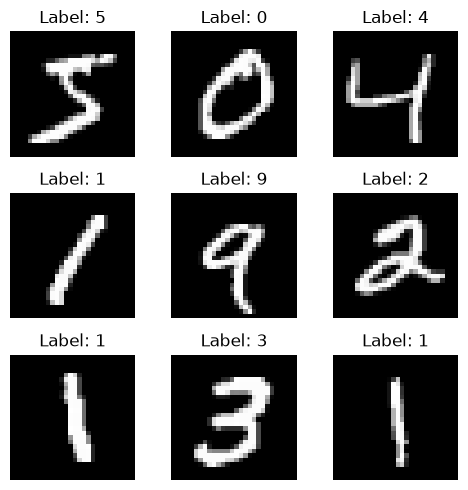

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(5,5))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
model = nn.Sequential(
    nn.Flatten(),           
    nn.Linear(784, 256),    
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),    
    nn.ReLU(),
    nn.Linear(128, 10)      
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss: {avg:.4f}")

Epoch 1/5  loss: 0.2967
Epoch 2/5  loss: 0.1226
Epoch 3/5  loss: 0.0878
Epoch 4/5  loss: 0.0693
Epoch 5/5  loss: 0.0568


In [5]:
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()

print(f"Test accuracy: {correct / len(test_data) * 100:.2f}%")

Test accuracy: 97.90%


In [6]:
torch.save(model.state_dict(), 'model.pth')
print("Model saved!")

Model saved!
